# Variance Swap Backtest
This was the part of the project I certianly learnt the most, from walk-foward validation methods to GARCH. I want to declare throughout bulding this I did ask AI's questions on how certian parts worked and why certain areas of my code were not working as I was unfamiliar with these methods of implmenting GARCH and walkfoward validation. However I have developed a understanding myself as well of these new areas and built on existing programming knowledge and statistics knowledge, I have used a vast amount of resources from differnt books such as Algothimic trading by P.Chan, Youtube sites in particlular Roman Pallouci and a vast number of sites teaching how to use python for finance. 

The mathematics behind the GARCH model have been outlined so now we can start to build the backtest. In this section I forecast future volatility and build our VRP over time, placing this then into a z-score signal which assumes the VRP will mean revert and enter postions based on if it meets the entry requirments. This entry requirement paramter is optmisied on a simple train and test back test. Currenlty, I only have PnL updating every 21 trading days meaning PnL only updates every 21 days, It would be intresting to make a mark-to-market daily PnL to look at pricing the variance swap in the secondary market. 

Areas for future improvment are: weighting postions on deviation from z score, as in trade a larger notional if the deviation from the rolling mean is larger and vice versa. Improving the volatiltiy modelling, as at the 'Meet UBS' event I met a Quant who didn't speak that highly of GARCH methods. 

Computionally, this is still quite slow. I am learning Data strcutures and Algorithms to learn ways to improve the run time of this notebook. 

In [2]:
import matplotlib.pyplot as plt
import pandas as pd   
import yfinance as yf
import numpy as np
import statsmodels.api as sm
import statistics
from arch import arch_model
import pickle

Here you can choose your index or single stock for stocks like tesla who have their own VIX equivlent. 

In [3]:
index = yf.download("^GSPC", start="1995-01-01", end="2026-09-10")
v_index = yf.download("^VIX", start="1995-01-01", end="2026-09-10")

prices_index = index["Close"].squeeze()
prices_v_index = v_index["Close"].squeeze()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [4]:
log_return_index_daily = np.log(prices_index).diff()
daily_var_index = log_return_index_daily ** 2
returns_index = 100 * prices_index.pct_change().dropna()

Here you can choose the length of the variance swap contract, this repesents a month variance swap currenlty at 21 trading days. This resembles ... mention colin bennets book 


In [5]:
window = 21

# Modelling future Volatitlity

In this section I model future voalitltiy, using GARCH. Below I outline the histogram of voalitltiy over the years, this gives us a good indication of the skewness and kurtoisis of the distrubtion of vol. Skewness is shown by the distrubiton being left of the mean volatitly as around 16% annulaised vol is typical for the S&P 500. The Kurtosis is shown by the right tail, showing the tail risk of short volaitlty strategies. Knowing the distrubtion of your volaitltiy is crucial to deciding your model for voaltitly, as distrubtions with large tails might be more suited to models like EGARCH.

0.17882749049032828


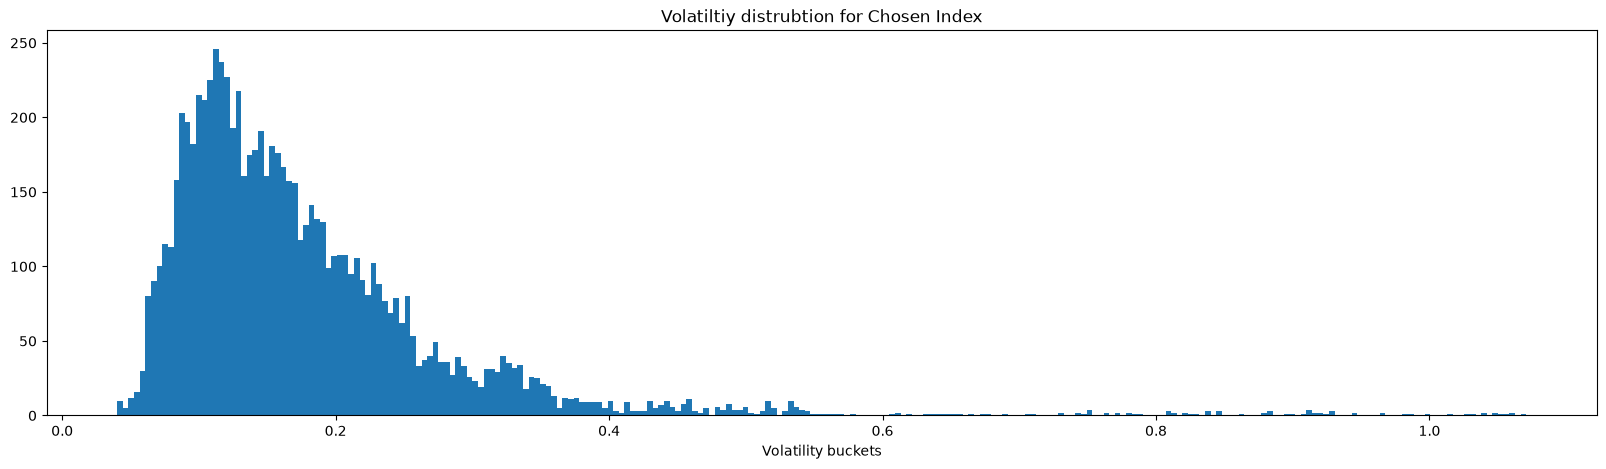

In [6]:
log_return_index_mean = log_return_index_daily.mean()
ri_minus_rmean_index = ((log_return_index_daily) - log_return_index_mean ) **2
sum_ri_minus_rmean_index = (((log_return_index_daily) - log_return_index_mean ) **2).rolling(window).sum()
var_index = (1/(len(log_return_index_daily) -1) * sum_ri_minus_rmean_index) * (252/window)
vol_index = np.sqrt(var_index) * 100
print(vol_index.mean())
plt.figure(figsize=(20,5))
plt.hist(vol_index, bins=250)
plt.title("Volatiltiy distrubtion for Chosen Index") 
plt.xlabel("Volatility buckets")
plt.show()

The GARCH model assumes clustering, here showing the autocorrelation tending towardds zero as n goes to intifity proves this clustering. This allows us to model our voaltiltiy using GARCH. 

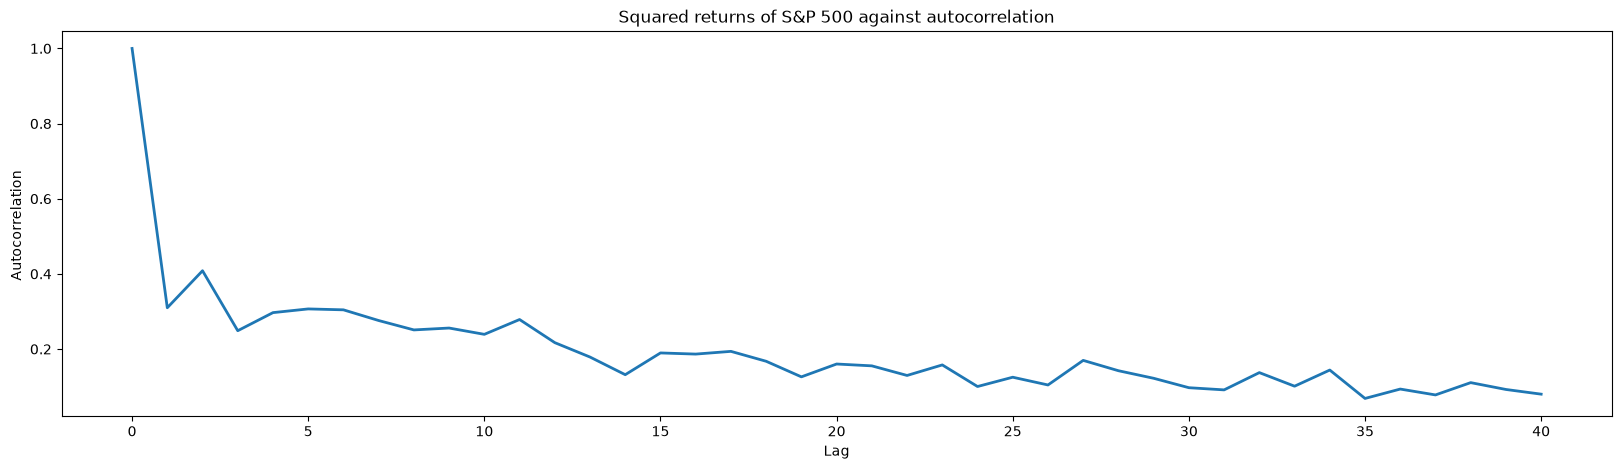

In [7]:
from statsmodels.graphics.tsaplots import acf
ln_rets_index = log_return_index_daily.dropna()
squared_index_returns = ln_rets_index ** 2
acf_index_values = acf(squared_index_returns, nlags=40)
plt.figure(figsize=(20,5))
plt.plot(acf_index_values, linewidth=2)
plt.title("Squared returns of S&P 500 against autocorrelation")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation ")
plt.show()

## Using GARCH

After Showing our volaitltiy is clustered. We can answer whay is GARCH? GARCH is Generalised Autoregresstive Condtional Herositkatisy. The formula for GARCH is below 

$$
\sigma_t^2 = \underbrace{\omega}_{\text{Long Run Term }} + \alpha\underbrace{\epsilon_{t-1}^2}_{\text{ARCH TERM}} + \beta\underbrace{\sigma_{t-1}^2}_{\text{GARCH TERM}}
$$ 

The first two terms are simply just the ARCH(1) developed by Engle, with $\alpha$ being the weighting on the recent shock(squared residual). The final term is what makes it our GARCH model. What we calcualte below is 

$$
E[\sigma_{t+k}^2] = \omega + E[\epsilon_{t+k-1}^2] + E[\sigma_{t+k-1}^2]
$$
here is the most elegant part connection connecting the last two terms in the previous equaiton. Our $\epsilon_{t+k-1}^2$ is one spefifi realised deviation from a small near zero mean squared. So when taking an conditonal expectation what is the information does $\epsilon_{t+k-1}^2$ poesses, we can say that 

$$ 
\epsilon_{t+k-1} = \sigma_{t+k-1} z_{t+k-1}
$$ 

Where the $z_{t+k-1}$ is indpendlety, indentically distrubted so all of the $z_{t}$ are of the same disturbiton. This why $E[z_{t+k-1}]=1$. this means when we take the conditoanl expectation 

$$
E[\epsilon_{t+k-1}^2] = E[\sigma_{t+k-1}^2] E[z_{t+k-1}^2] = E[\sigma_{t+k-1}^2]
$$
Now this is useful as we can plug this into our GARCH Formula to see:
$$
E[\sigma_{t+k}^2] = \omega + (\alpha + \beta)E[\sigma_{t+k-1}^2]
$$
From Condtional expecation we see 
$$
E[\sigma_{t+k}^2] = \omega + (\alpha + \beta)E[\sigma_{t+k-1}^2] = \omega + (\alpha + \beta)(\omega + (\alpha + \beta)E[\sigma_{t+k-2}^2]
$$
We can see this is recursive so using our geometric series formula $ \sum{a_i}_{i=0}^{k} = \frac{1-a^k}{1-a}$ apply this to the coefficant of the $\omega$ term we gain:
$$
E[\sigma_{t+k}^2] = \omega \left(\frac{1-(\alpha +\beta)^k}{1-(\alpha + \beta)}\right) + (\alpha + \beta)^kE[\sigma_{t}^2]
$$
This shows to us a very important condtion called our 'staionarity conditon', as seen below. I first ran into this concept of stainoarity when building a pairs trading project. Staionarity says that a process has 3 constant parts: constant mean, constant variance and constant autocovariance strucutre. This is very apt to the project as we assume that the VRP has a constant mean value over the whole time period, another very key assumption is that the size of the fulcations is constnat. However, this is excatly what GARCH models vialtions of. 
$$
\alpha + \beta < 1
$$
Now to adress the walk-foward validation. So in the previous equations $\omega$, $\alpha$ and $\beta$ have all been constant. This is what our walk-foward validation adresses. Each fold the best paratmer which best fits the data in that fold is chosen, so we have for each fold a recurison formula. One thing to highlight is how the validaiton process actually works
$$
\text{Training Period}_1 \subset \text{Training Period}_2 \subset ..... \subset \text{Training Period}_k
$$
So for each fold we have $ j= 0, ....., \text{horizon} $ 
$$
E[\sigma_{t_k + j}^2] = \omega \left(\frac{1-(\alpha +\beta)^j}{1-(\alpha + \beta)}\right) + (\alpha + \beta)^jE[\sigma_{t_k}^2]
$$

<Axes: title={'center': 'Forecasted Vs Realised Returns'}, xlabel='Time', ylabel='Volatility'>

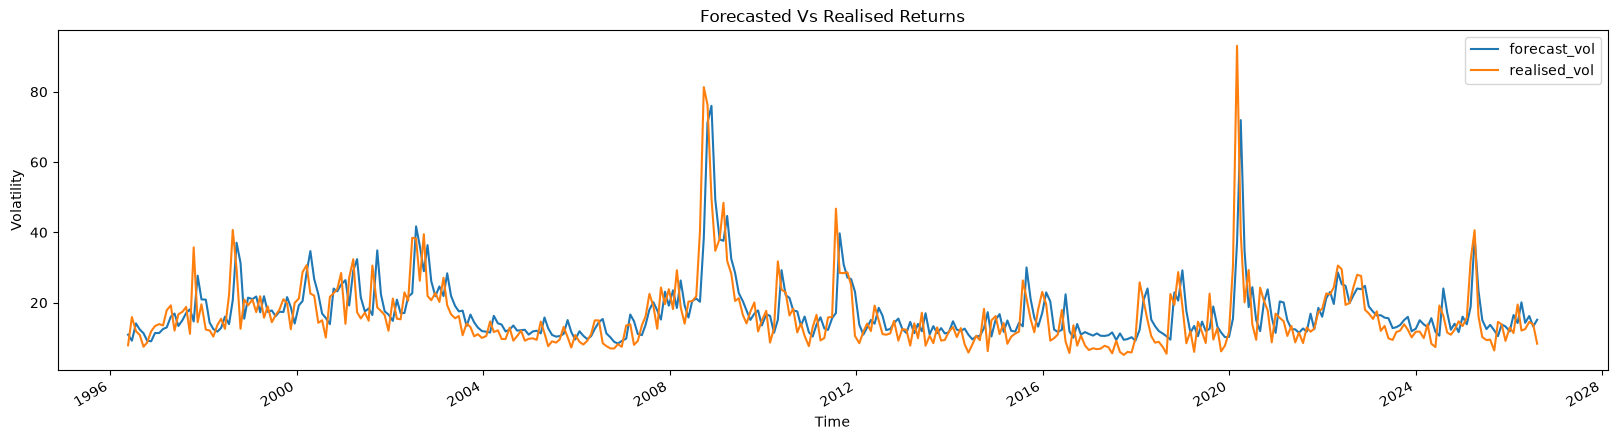

In [8]:
def walk_forward_validation(returns, min_train=350, horizon=21, p=1, q=1, dist='normal'):

    results = []
    n = len(returns)
    start= min_train
    while start + horizon <= n:
        train_data = returns.iloc[:start]
        model = arch_model(train_data, vol='Garch', p=p, q=q, dist=dist)
        fit = model.fit(disp='off')
        fc = fit.forecast(horizon=horizon, reindex=False)
        forecast_var = fc.variance.iloc[-1].sum() / 10000

        Forecast_date = returns.index[start - 1]
        realised_var = (returns.iloc[start : start + horizon] / 100 ) ** 2
        realised_var_sum = realised_var.sum()

        results.append({'forecast_start': Forecast_date, 'forecasted variance': forecast_var, 'realised variance': realised_var_sum,})
        start += horizon

    return pd.DataFrame(results).set_index('forecast_start')

wf_results = walk_forward_validation(returns_index, min_train=350, horizon=21)

wf_results['forecast_vol'] = np.sqrt(wf_results['forecasted variance'] * (252/21)) * 100
wf_results['realised_vol'] = np.sqrt(wf_results['realised variance'] * (252/21)) * 100
wf_results[['forecast_vol', 'realised_vol']].plot(figsize=(20, 5),  xlabel='Time', ylabel='Volatility', title='Forecasted Vs Realised Returns')

# Using the VIX as a proxy for the fair strike and Defining Our VRP
Now we implement the idea built upon in the previous ..... section. We define our VRP as being 

$$
VRP = E_t^Q[Var_t] - E_t^P[Var_t]
$$
we are using the variance forecast from our GARCH model and our implied volatlity from the VIX, here below we see the pred

0.0008160127363927899


<Axes: title={'center': '$K_{Var}$ Vs Realised Variance'}, xlabel='Time', ylabel='Variance'>

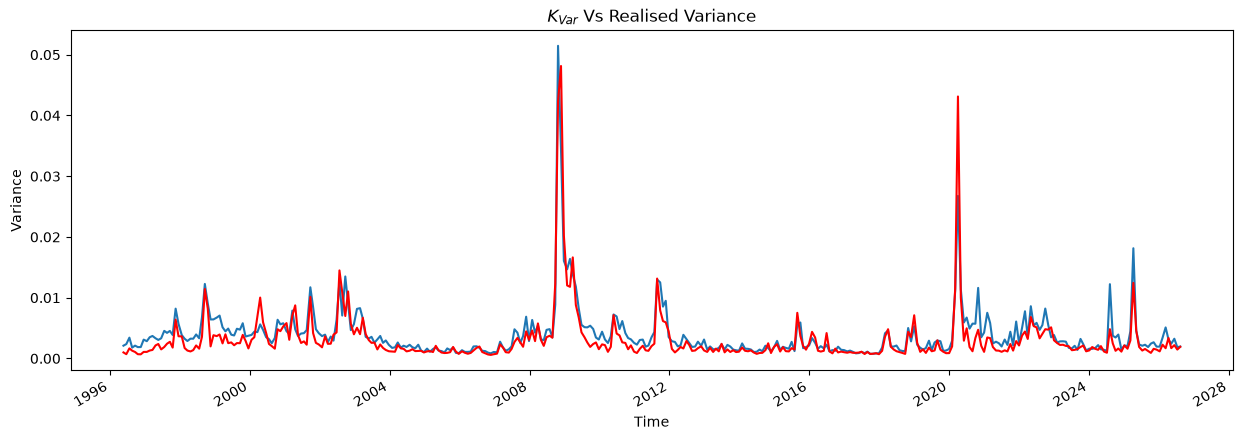

In [9]:
Kvar_index = ((prices_v_index / 100) ** 2 ) *( 30/365)
Kvar_aligned = Kvar_index.reindex(wf_results.index)
VRP_index = Kvar_aligned - (wf_results['forecasted variance'])
print(VRP_index.mean())
Kvar_aligned.plot(figsize=(20,5))
wf_results['forecasted variance'].plot(figsize=(15,5), color='Red',  xlabel='Time', ylabel='Variance', title='$K_{Var}$ Vs Realised Variance',)

This is an important step using a rolling mean, to avoid a look forward bias.
$$
Z_{VRP} = \frac{VRP - \hat{VRP}}{\sigma_{VRP}}
$$
This creates a Series that contains the Z scores for the 21 rolling day periods. 

In [10]:
# Define for a sample mean 
roll_VRP_mean = VRP_index.expanding(min_periods=12).mean().shift(1)
roll_VRP_std = VRP_index.expanding(min_periods=12).std().shift(1)
z_series = ((VRP_index - roll_VRP_mean) / roll_VRP_std).dropna()

## Signal Generation 
This is the same signal created in the orginal version. If the z-score of the VRP is greater than 'entry_req', then short volaittily as this tells us that the market is over expecting future volatitliy. This part is where we make the crucial assumption of mean reversion. However, a recent improvemtn to this strategy is adding of the 'entry_short_req' and 'entry_long_req' this is because when I realised the paramter optimasation was choosing a close to zero value, This makes sense as $ VRP > 0 $

In [11]:
def signal(z_series, entry_long_req, entry_short_req,window):
    position = 0
    positions = [] #  currenlty have an empty book
    Days_in_trade = 0
    
    for z in z_series:
        enter_today = 0 
        if position == 0:
            if z > entry_short_req:
                position = -1
                enter_today = -1
                Days_in_trade = 0
            elif z < - entry_long_req:
                position = 1
                enter_today = 1
                Days_in_trade = 0
        else:
            Days_in_trade += 1
            if Days_in_trade >= 1:
                    position = 0 
        positions.append(enter_today if position != 0 else 0)
    return pd.Series(positions, index= z_series.index)


## Optmisation of entry paramters 
This section optmisies the entry parameters of the z-score, it finds the best one. The for loop here is certainly making the code slower. 

In [12]:
def simple_train_test_backtest(z_series, entry_candidates, train_frac=0.4, hold_window=window):
    split_idx = int(len(z_series) * train_frac)
    train_z = z_series.iloc[:split_idx]
    test_z = z_series.iloc[split_idx:]
    best_short_req = None 
    best_long_req = None
    best_score = -np.inf

    for long_req in entry_candidates:
         for short_req in entry_candidates:
             places = signal(train_z, long_req, short_req, hold_window)
             variance_swap__short_pnl = places.shift(1) * (wf_results['forecasted variance'] - Kvar_aligned)
             score = variance_swap__short_pnl.sum()

             if score > best_score:
                 best_score = score
                 best_short_req = short_req
                 best_long_req = long_req
       
    print(f"Chosen entry candidate for short postions: {best_short_req}")
    print(f"Chosen entry candidate for long postions: {best_long_req}")
    train_positions = signal(train_z, best_long_req, best_short_req, hold_window) 
    test_positions = signal(test_z, best_long_req ,best_short_req, hold_window)
    return train_positions, test_positions, best_long_req, best_short_req
   
    
train_positions, test_positions, best_long_req , best_short_req = simple_train_test_backtest(
    z_series.dropna(),
    entry_candidates=[i / 100 for i in range(1, 200)],
    train_frac=0.726,
    hold_window=window
)


Chosen entry candidate for short postions: 0.01
Chosen entry candidate for long postions: 1.53


# PnL and Metrics 
After choosing the best entry requirments we have to solve for changign from variance points to our notional amount to find the payoff for each contract th

In [13]:
def cumlative_pnl(positions, realized_variance_series):
    lagged_positions = positions.shift(1).fillna(0)
    pnl = -lagged_positions * realized_variance_series.diff()
    cumlative_pnl = pnl.cumsum()
    return cumlative_pnl
    
train_cumlative_pnl = cumlative_pnl(train_positions, daily_var_index.loc[train_positions.index])
test_cumlative_pnl = cumlative_pnl(test_positions, daily_var_index.loc[test_positions.index])    

In [14]:
def pnl(positions, realized_variance_series):
    lagged_positions = positions.shift(1).fillna(0)
    pnl = -lagged_positions * realized_variance_series.diff()
    return pnl
    
test_pnl = pnl(test_positions, daily_var_index.loc[test_positions.index])
train_pnl = pnl(train_positions, daily_var_index.loc[train_positions.index])   

### Cumlative Returns over time
Here we see the strategies cumlative returns over time, with the red line showing the split betwen the test and train sample data.

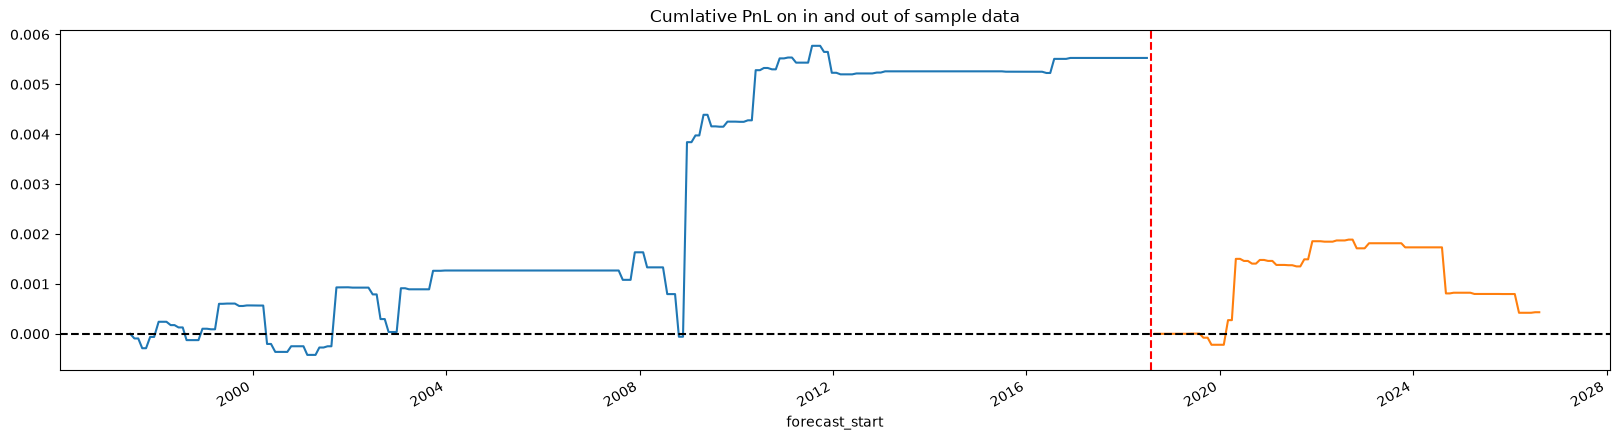

In [15]:
train_cumlative_pnl.plot()
test_cumlative_pnl.plot(figsize=(20,5), title='Cumlative PnL on in and out of sample data')
plt.axhline(0, linestyle='--', color='Black')
split = int(len(z_series) * 0.726)
plt.axvline(z_series.index[split], linestyle='--', color='Red')

### Cumlative Returns
These returns are a bit disappoting, in the next section I will analyse why the stratergy has returned this poorly. 

In [16]:
test_pnl = pnl(test_positions, daily_var_index.loc[test_positions.index])
train_pnl = pnl(train_positions, daily_var_index.loc[train_positions.index])
cumlative_return_test = (((1 + test_pnl).prod() -1 ) * 100).round(2).astype('str') + '%'
cumlative_return_train = (((1 + train_pnl).prod() -1 ) * 100).round(2).astype('str') + '%'
print(cumlative_return_test)
print(cumlative_return_train)

0.04%
0.55%


### Sharpe ratio

In [17]:
sharpe_ratio_test = (test_pnl.mean() / test_pnl.std()) * np.sqrt(252)
sharpe_ratio_train = (train_pnl.mean() / train_pnl.std()) * np.sqrt(252)

print(sharpe_ratio_test)
print(sharpe_ratio_train)

0.403126364490919
1.170454375511884


### Notional Returns
As we can see here the inflation adjusted returns would be horrible

<Axes: title={'center': 'Return of 1 million pounds'}, xlabel='Time', ylabel='Millions of Pounds'>

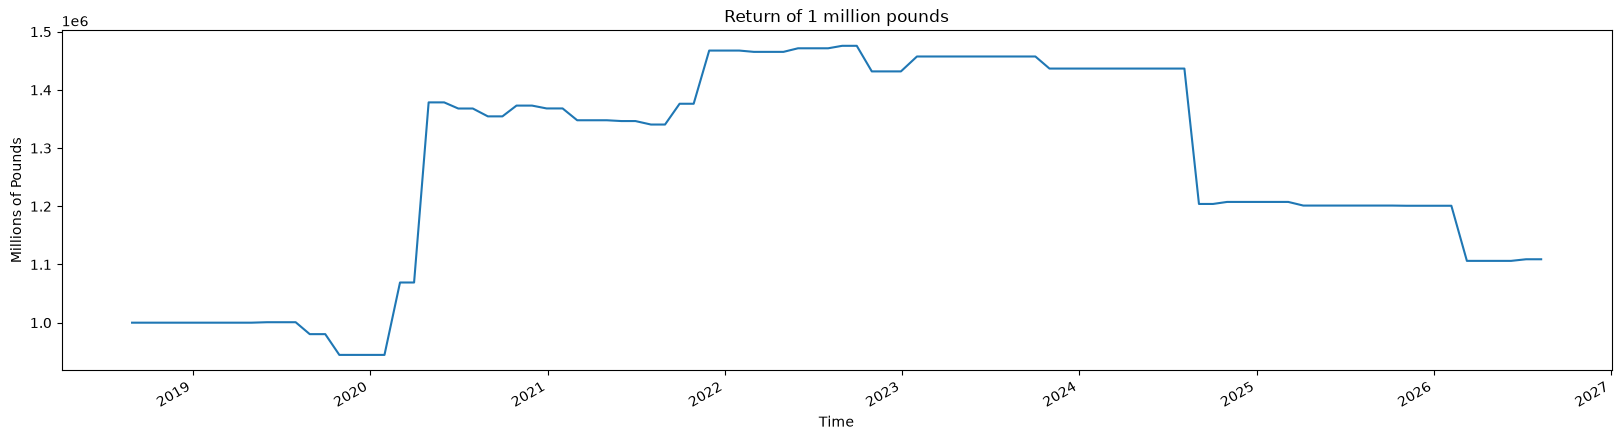

In [18]:
notional = 1_000_000  
pnl_annualized_variance_points = test_pnl * 252          
pnl_pounds = pnl_annualized_variance_points * notional 
total_pounds_ret = pnl_pounds.cumsum() + notional
total_pounds_ret.plot(figsize=(20,5), xlabel='Time' ,ylabel='Millions of Pounds', title='Return of 1 million pounds')

### Drawdowns

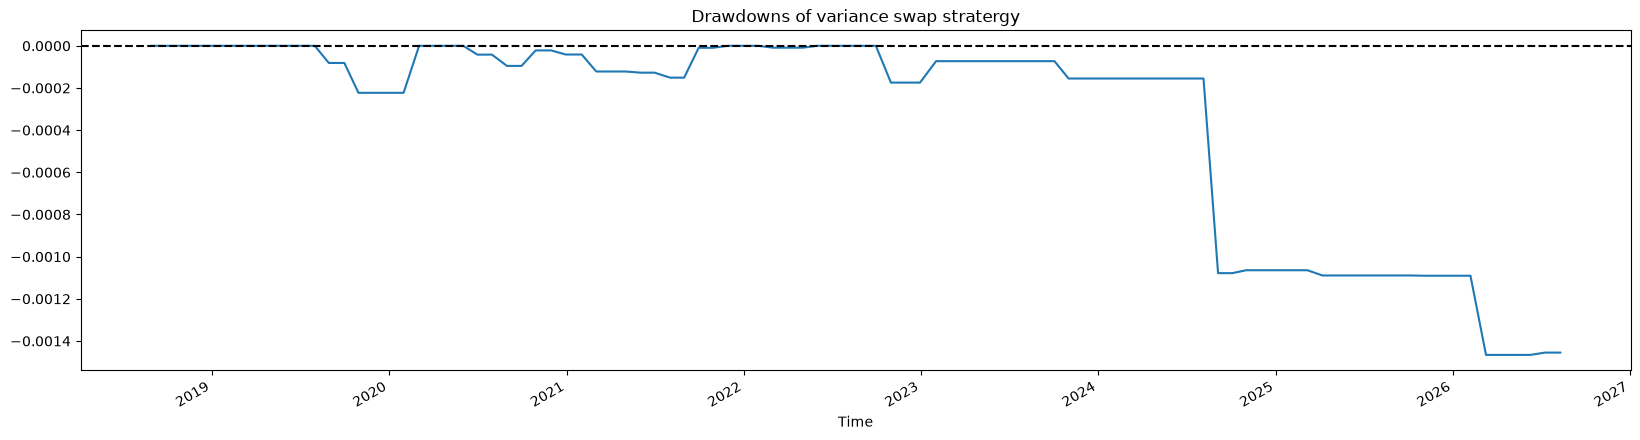

In [19]:
wealth_index = (test_pnl +1).cumprod()
previous_peaks = wealth_index.cummax()
drawdowns = (wealth_index - previous_peaks) / previous_peaks
drawdowns.plot(figsize=(20,5),  xlabel='Time'  ,title='Drawdowns of variance swap stratergy')
plt.axhline(0, linestyle='--', color='Black')

# Conculsion
This is a apt place to end. In this section I have compelted a walk foward validation of garch to avoid overfitting in our Volatitly forecasting, and completed a simple train test back test on the z-score mean reversion aspect, finding an optimised paramter for entering a postion. Then using this I create a cumlative and standard Pnl for the in and out of sample tests. This now leads us to ask questions about why the strategy has returned like this? Where is the PnL coming from? How does it compare to being run on other incides? 

In [20]:
data_backtest_spx = {
    'test_pnl_spx': test_pnl,
    'train_pnl_spx': train_pnl,
    'test_positions_spx': test_positions,
    'train_positions_spx': train_positions,
    'test_cumlative_pnl_spx': test_cumlative_pnl,
    'cumlative_return_test_spx': cumlative_return_test,
    'VRP_index_spx': VRP_index,
    'z_series_spx': z_series,
    'wf_results_spx': wf_results,
    'Kvar_aligned_spx': Kvar_aligned,
    'best_short_req': best_short_req,
    'best_long_req': best_long_req
}
import pickle
with open("Backtest_data_spx.pkl", "wb") as f:
    pickle.dump(data_backtest_spx, f)



## List of Resources Used
P.Chan's Algorithmtic Trading

Hamiltion, Time Series Analysis

QuantConnect's walk-forward optimization docs#

Roman Pallocui's Youtube videos

PyQuant

Dainel Boctor's Youtube videos

MIT OCW Time Series Analysis

https://www.quantt.co.uk/resources/time-series-analysis-guide